# 00 · Dataset audit — Who Is AI

Notebook này audit dữ liệu trước khi tạo split và huấn luyện. Trọng tâm gồm chất lượng/metadata, khác biệt màu sắc Real/Fake, shortcut tiềm năng và khả năng xác định source/generator.

Notebook chỉ đọc ảnh gốc; các bảng và hình được ghi vào `outputs/dataset_audit/`. Public/private test không có nhãn trong dữ liệu hiện tại nên chỉ được kiểm kê, không tính metric.

In [9]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageOps
from IPython.display import display

SEED = 42
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
random.seed(SEED)
np.random.seed(SEED)

# Tìm repo root để notebook chạy được từ thư mục repo hoặc notebooks/.
def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "docs" / "week02.md").exists() and (candidate / "data" / "Who_is_AI" / "data").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy repo FaceTrace hoặc data/Who_is_AI/data.")

REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "Who_is_AI" / "data"
TRAIN_ROOT = DATA_ROOT / "train"
MANIFEST_PATH = TRAIN_ROOT / "manifest.csv"
OUTPUT_DIR = REPO_ROOT / "outputs" / "dataset_audit"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo:", REPO_ROOT)
print("Data:", DATA_ROOT)
print("Output:", OUTPUT_DIR)

Repo: /home/toska/code/aio/FaceTrace
Data: /home/toska/code/aio/FaceTrace/data/Who_is_AI/data
Output: /home/toska/code/aio/FaceTrace/outputs/dataset_audit


## 1. Nạp manifest và kiểm tra cấu trúc

Manifest hiện dùng `path`, `label`, `class_name`; đường dẫn ảnh tương đối từ thư mục `train/`. Không tự tạo source/generator nếu metadata không có.

In [10]:
manifest = pd.read_csv(MANIFEST_PATH)
required_columns = {"path", "label"}
missing_columns = required_columns - set(manifest.columns)
if missing_columns:
    raise ValueError(f"Manifest thiếu cột bắt buộc: {sorted(missing_columns)}")

manifest["path"] = manifest["path"].astype(str)
manifest["image_path"] = manifest["path"].map(lambda p: str((TRAIN_ROOT / p).resolve()) if not Path(p).is_absolute() else p)
manifest["exists"] = manifest["image_path"].map(lambda p: Path(p).is_file())
manifest["label_name"] = manifest["class_name"] if "class_name" in manifest else manifest["label"].map({0: "Real", 1: "Fake", "0": "Real", "1": "Fake"}).fillna(manifest["label"].astype(str))

print(f"Rows: {len(manifest):,}")
print("Columns:", list(manifest.columns))
print("Missing paths:", int((~manifest["exists"]).sum()))
display(manifest.head())
display(manifest.groupby(["label", "label_name"], dropna=False).size().rename("count").reset_index())

source_candidates = [c for c in manifest.columns if any(key in c.lower() for key in ("source", "generator", "model_name", "dataset"))]
print("Possible source/generator columns:", source_candidates or "None found")
if not source_candidates:
    print("LIMITATION: chưa có source/generator metadata trong manifest; random split không thể được gọi là unseen-source evaluation.")

Rows: 2,000
Columns: ['label', 'class_name', 'path', 'image_path', 'exists', 'label_name']
Missing paths: 0


,label,class_name,path,image_path,exists,label_name
0,0,Real,images/00079.jpg,/home/toska/code/aio/FaceTrace/data/Who_is_AI/...,True,Real
1,0,Real,images/00586.jpg,/home/toska/code/aio/FaceTrace/data/Who_is_AI/...,True,Real
2,0,Real,images/01426.jpg,/home/toska/code/aio/FaceTrace/data/Who_is_AI/...,True,Real
3,0,Real,images/01562.jpg,/home/toska/code/aio/FaceTrace/data/Who_is_AI/...,True,Real
4,0,Real,images/00295.jpg,/home/toska/code/aio/FaceTrace/data/Who_is_AI/...,True,Real


,label,label_name,count
0,0,Real,1000
1,1,Fake,1000


Possible source/generator columns: None found
LIMITATION: chưa có source/generator metadata trong manifest; random split không thể được gọi là unseen-source evaluation.


## 2. Kiểm tra toàn bộ ảnh và trích xuất đặc trưng EDA

Ảnh có thể được lưu/giải mã ở mode RGB nhưng nội dung gần grayscale. Vì vậy phân loại màu dùng giá trị pixel: `gray_pixel_fraction` là tỷ lệ pixel có max(R,G,B) − min(R,G,B) ≤ 2. `gray_like_image` đánh dấu ảnh có ít nhất 99% pixel gần grayscale; đây là ngưỡng mô tả để audit, không phải nhãn dữ liệu.

Saturation được đo trong HSV; độ sáng dùng luminance xấp xỉ Rec. 601. Edge density là chỉ báo thô về độ chi tiết/nét, không phải đánh giá chất lượng ảnh.

In [11]:
split_image_dirs = {}
for split_name in ("train", "public_test", "private_test"):
    split_root = DATA_ROOT / split_name
    image_dirs = [p for p in split_root.rglob("images") if p.is_dir()] if split_root.exists() else []
    if image_dirs:
        split_image_dirs[split_name] = image_dirs[0]
    else:
        print(f"Không tìm thấy thư mục images cho split: {split_name}")

train_by_name = manifest.drop_duplicates("path").set_index(manifest["path"].map(lambda p: Path(p).name), drop=False)
image_rows = []
hash_to_paths = defaultdict(list)
color_hist = {name: {channel: np.zeros(32, dtype=np.int64) for channel in ("R", "G", "B")} for name in ("Real", "Fake")}
luma_hist = {name: np.zeros(32, dtype=np.int64) for name in ("Real", "Fake")}
saturation_hist = {name: np.zeros(32, dtype=np.int64) for name in ("Real", "Fake")}

for split_name, images_dir in split_image_dirs.items():
    paths = sorted(p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
    print(f"{split_name}: {len(paths):,} ảnh")
    for path in paths:
        row = {"split": split_name, "image_id": f"{split_name}/{path.name}", "file_name": path.name,
               "image_path": str(path.resolve()), "extension": path.suffix.lower(),
               "file_size_bytes": path.stat().st_size, "label": None, "label_name": None,
               "source": None, "valid_image": False}
        if split_name == "train" and path.name in train_by_name.index:
            manifest_row = train_by_name.loc[path.name]
            if isinstance(manifest_row, pd.DataFrame):
                manifest_row = manifest_row.iloc[0]
            row["label"] = manifest_row["label"]
            row["label_name"] = manifest_row["label_name"]
            for col in source_candidates:
                row["source"] = manifest_row[col]
                break
        try:
            digest = hashlib.sha256(path.read_bytes()).hexdigest()
            hash_to_paths[digest].append(row["image_id"])
            with Image.open(path) as image:
                row.update({"valid_image": True, "format": image.format, "mode": image.mode,
                            "width": image.width, "height": image.height,
                            "exif_fields": len(image.getexif()),
                            "exif_software": image.getexif().get(305),
                            "jpeg_quantization_tables": len(getattr(image, "quantization", {}))})
                rgb = ImageOps.exif_transpose(image).convert("RGB")
                arr = np.asarray(rgb, dtype=np.uint8)
                arr16 = arr.astype(np.int16)
                channel_range = arr16.max(axis=2) - arr16.min(axis=2)
                gray_fraction = float(np.mean(channel_range <= 2))
                hsv = np.asarray(rgb.convert("HSV"), dtype=np.uint8)
                luminance = (0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]).astype(np.uint8)
                row.update({
                    "gray_pixel_fraction": gray_fraction,
                    "gray_like_image": gray_fraction >= 0.99,
                    "mean_R": float(arr[:, :, 0].mean()), "mean_G": float(arr[:, :, 1].mean()), "mean_B": float(arr[:, :, 2].mean()),
                    "std_R": float(arr[:, :, 0].std()), "std_G": float(arr[:, :, 1].std()), "std_B": float(arr[:, :, 2].std()),
                    "mean_luminance": float(luminance.mean()), "std_luminance": float(luminance.std()),
                    "mean_saturation": float(hsv[:, :, 1].mean()), "std_saturation": float(hsv[:, :, 1].std()),
                    "edge_mean": float(np.asarray(rgb.convert("L").filter(ImageFilter.FIND_EDGES), dtype=np.uint8).mean()),
                })
                label_name = row["label_name"]
                if label_name in color_hist:
                    for channel, idx in (("R", 0), ("G", 1), ("B", 2)):
                        color_hist[label_name][channel] += np.histogram(arr[:, :, idx], bins=32, range=(0, 256))[0]
                    luma_hist[label_name] += np.histogram(luminance, bins=32, range=(0, 256))[0]
                    saturation_hist[label_name] += np.histogram(hsv[:, :, 1], bins=32, range=(0, 256))[0]
                row["jpeg_qtable_fingerprint"] = hashlib.sha1(repr(getattr(image, "quantization", {})).encode()).hexdigest()[:12] if image.format == "JPEG" else None
        except Exception as exc:
            row["error"] = repr(exc)
        image_rows.append(row)

image_audit = pd.DataFrame(image_rows)
print("Audited images:", len(image_audit), "| invalid:", int((~image_audit["valid_image"]).sum()))
display(image_audit.groupby(["split", "label_name"], dropna=False).size().rename("images").reset_index())

train: 2,000 ảnh
public_test: 200 ảnh
private_test: 200 ảnh
Audited images: 2400 | invalid: 0


,split,label_name,images
0,private_test,NaN,200
1,public_test,NaN,200
2,train,Fake,1000
3,train,Real,1000


## 3. Thống kê theo lớp và shortcut tiềm năng

So sánh thống kê **theo từng ảnh** giữa Real/Fake; không chỉ dựa trên histogram pixel gộp. Kiểm tra đặc biệt grayscale, saturation, độ sáng, tương phản, kích thước file và EXIF.

,split,label_name,n_images,n_gray_like,gray_like_fraction,n_formats,formats,file_size_bytes_mean,file_size_bytes_std,file_size_bytes_median,...,edge_mean_median,mean_R_mean,mean_R_std,mean_R_median,mean_G_mean,mean_G_std,mean_G_median,mean_B_mean,mean_B_std,mean_B_median
0,train,Fake,1000,500,0.5,1,JPEG,58701.534,14247.352550,57690.5,...,8.247614,118.521489,27.836956,118.345007,108.540493,26.289180,107.191545,103.214409,28.013086,102.336075
1,train,Real,1000,500,0.5,1,JPEG,69080.823,14361.159328,67707.5,...,10.627920,123.024634,30.301949,121.985411,110.654078,28.711268,109.188595,105.266995,30.834959,104.564493


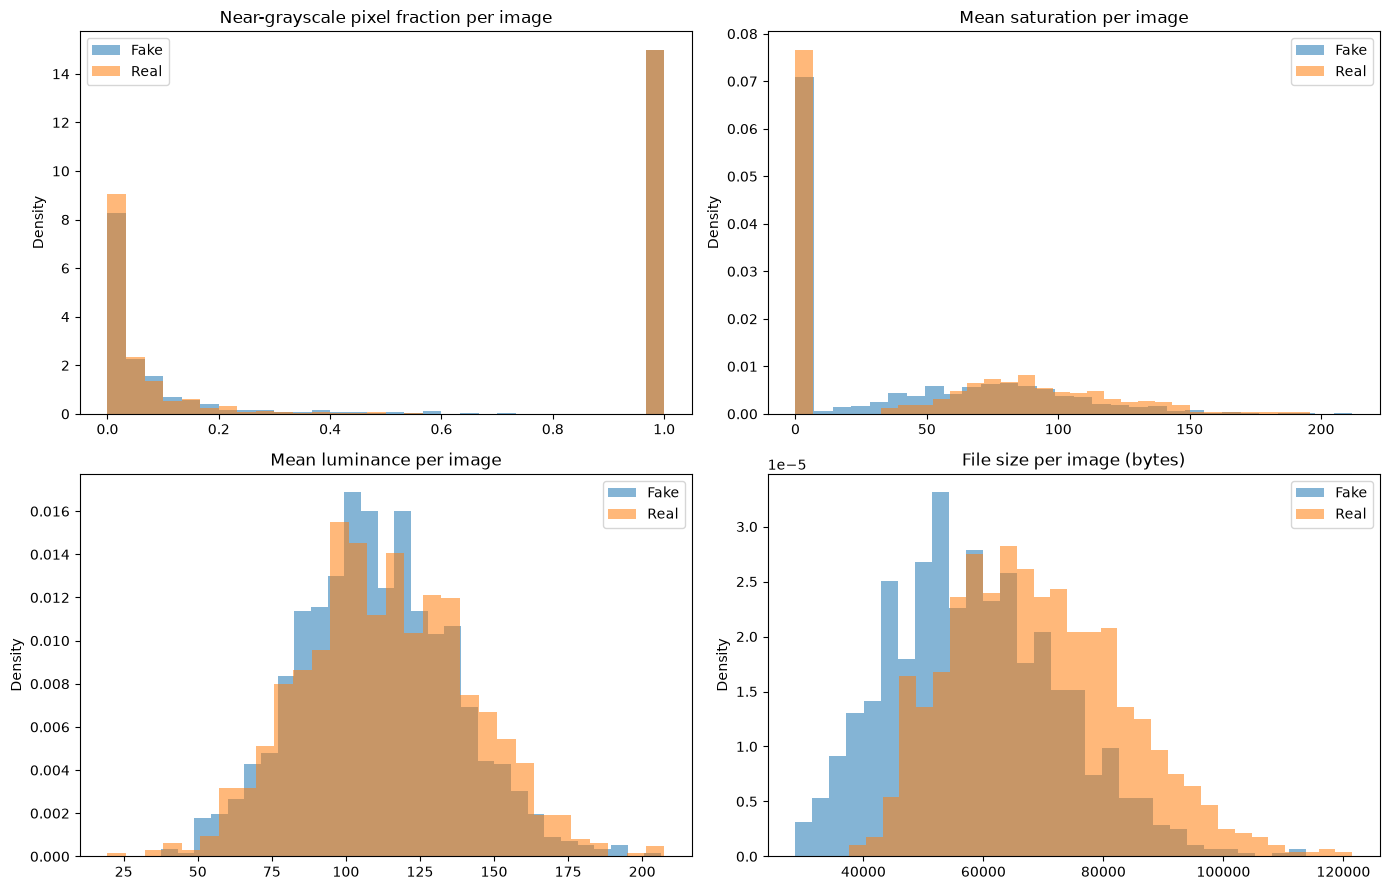

In [12]:
train_audit = image_audit[(image_audit["split"] == "train") & image_audit["valid_image"]].copy()
feature_columns = ["file_size_bytes", "width", "height", "gray_pixel_fraction", "mean_saturation",
                   "mean_luminance", "std_luminance", "edge_mean", "mean_R", "mean_G", "mean_B"]
summary_rows = []
for label_name, group in train_audit.groupby("label_name", dropna=False):
    row = {"split": "train", "label_name": label_name, "n_images": len(group),
           "n_gray_like": int(group["gray_like_image"].sum()),
           "gray_like_fraction": float(group["gray_like_image"].mean()),
           "n_formats": group["format"].nunique(), "formats": ", ".join(sorted(group["format"].dropna().unique()))}
    for col in feature_columns:
        row[f"{col}_mean"] = float(group[col].mean())
        row[f"{col}_std"] = float(group[col].std())
        row[f"{col}_median"] = float(group[col].median())
    summary_rows.append(row)
summary = pd.DataFrame(summary_rows)
display(summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feature, title in zip(axes.flat,
                             ["gray_pixel_fraction", "mean_saturation", "mean_luminance", "file_size_bytes"],
                             ["Near-grayscale pixel fraction per image", "Mean saturation per image", "Mean luminance per image", "File size per image (bytes)"]):
    for label_name, group in train_audit.groupby("label_name"):
        ax.hist(group[feature].dropna(), bins=30, alpha=0.55, density=True, label=label_name)
    ax.set_title(title); ax.set_ylabel("Density"); ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "image_level_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Histogram pixel theo lớp

Các histogram dưới đây được chuẩn hóa riêng theo tổng số pixel mỗi lớp. Chúng cho thấy khác biệt phân bố tổng thể, nhưng bị ảnh hưởng bởi nội dung, khuôn mặt và background; cần đọc cùng thống kê image-level và montage.

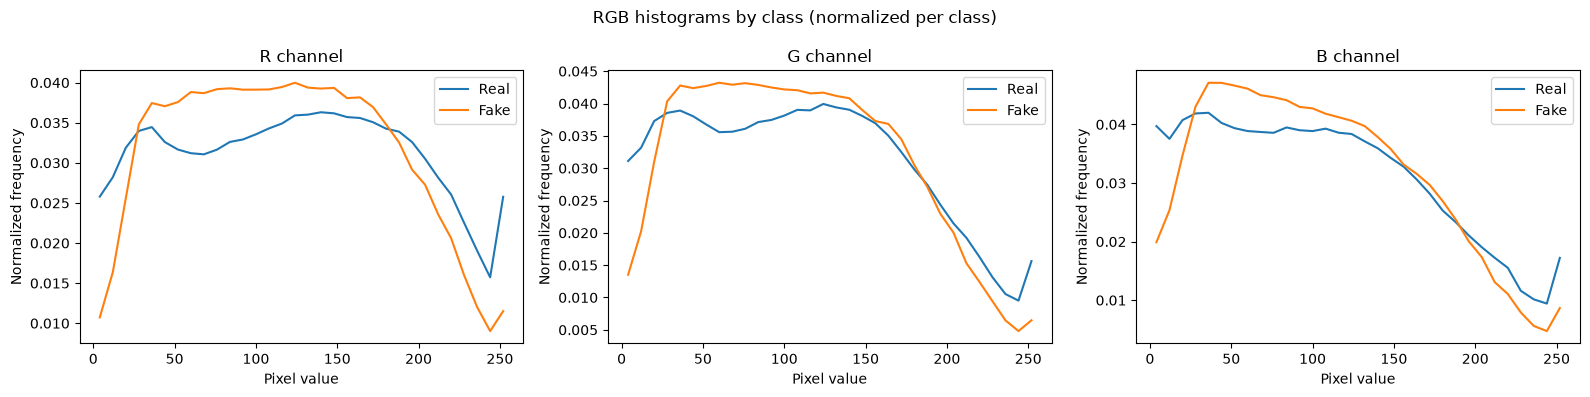

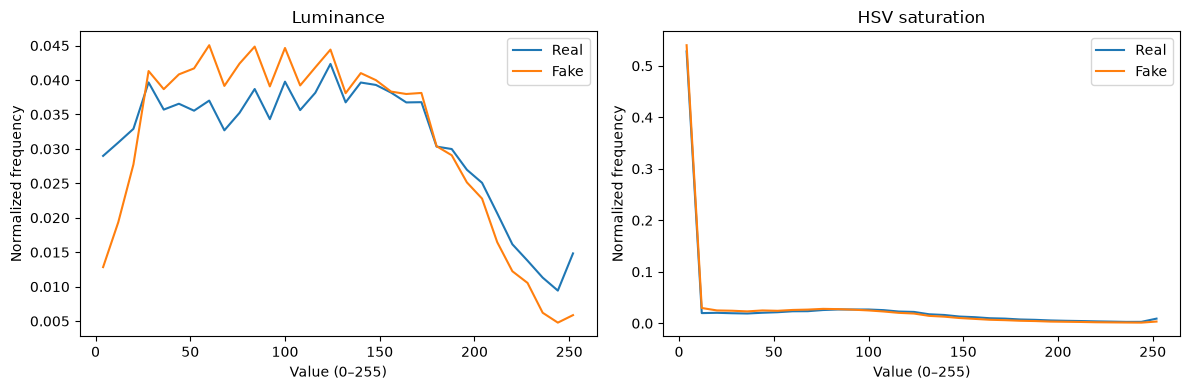

In [13]:
labels = [name for name in ("Real", "Fake") if name in color_hist]
centers = np.arange(32) * 8 + 4
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, channel in zip(axes, ("R", "G", "B")):
    for label_name in labels:
        counts = color_hist[label_name][channel]
        density = counts / max(counts.sum(), 1)
        ax.plot(centers, density, label=label_name)
    ax.set_title(f"{channel} channel"); ax.set_xlabel("Pixel value"); ax.set_ylabel("Normalized frequency"); ax.legend()
fig.suptitle("RGB histograms by class (normalized per class)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "rgb_histograms_by_class.png", dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label_name in labels:
    for ax, counts, title in ((axes[0], luma_hist[label_name], "Luminance"), (axes[1], saturation_hist[label_name], "HSV saturation")):
        ax.plot(centers, counts / max(counts.sum(), 1), label=label_name)
        ax.set_title(title); ax.set_xlabel("Value (0–255)"); ax.set_ylabel("Normalized frequency")
        ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "luminance_saturation_histograms.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Kiểm tra trùng lặp, đường dẫn và metadata

Hash SHA-256 chỉ phát hiện duplicate byte-identical; ảnh gần trùng (resize/re-encode) cần bước perceptual hash riêng nếu cần. JPEG quantization table fingerprint là tín hiệu sàng lọc encoding khác nhau, không phải phép đo chính xác JPEG quality.

In [14]:
duplicate_groups = [paths for paths in hash_to_paths.values() if len(paths) > 1]
missing_manifest = manifest.loc[~manifest["exists"], ["path", "label", "label_name"]]
manifest_names = set(manifest["path"].map(lambda p: Path(p).name))
train_files = set(image_audit.loc[image_audit["split"] == "train", "file_name"])
images_without_manifest = sorted(train_files - manifest_names)

print("Exact duplicate groups:", len(duplicate_groups))
print("Images in duplicate groups:", sum(map(len, duplicate_groups)))
print("Manifest paths missing on disk:", len(missing_manifest))
print("Train images without manifest row:", len(images_without_manifest))
print("Source/generator metadata:", source_candidates or "not present")

for split_name, group in image_audit.groupby("split"):
    print(f"{split_name}: formats={group['format'].value_counts(dropna=False).to_dict()}, modes={group['mode'].value_counts(dropna=False).to_dict()}, dimensions={group.groupby(['width','height'], dropna=False).size().to_dict()}")

# Những EXIF/JPEG encoding khác nhau giữa hai lớp có thể gợi ý pipeline khác nhau.
if "jpeg_qtable_fingerprint" in train_audit:
    display(pd.crosstab(train_audit["label_name"], train_audit["jpeg_qtable_fingerprint"], normalize="index"))
if "exif_software" in train_audit:
    display(pd.crosstab(train_audit["label_name"], train_audit["exif_software"].fillna("<no EXIF software>")))

Exact duplicate groups: 0
Images in duplicate groups: 0
Manifest paths missing on disk: 0
Train images without manifest row: 0
Source/generator metadata: not present
private_test: formats={'JPEG': 200}, modes={'RGB': 200}, dimensions={(512, 512): 200}
public_test: formats={'JPEG': 200}, modes={'RGB': 200}, dimensions={(512, 512): 200}
train: formats={'JPEG': 2000}, modes={'RGB': 2000}, dimensions={(512, 512): 2000}


jpeg_qtable_fingerprint,314681324ff3
label_name,
Fake,1.0
Real,1.0


exif_software,<no EXIF software>
label_name,
Fake,1000
Real,1000


## 6. Montage định tính cân bằng

Montage lấy mẫu cố định theo seed. Nhìn riêng Real/Fake và màu/gần grayscale để phát hiện pattern về crop, background, ánh sáng hoặc dấu hiệu tiền xử lý. Một vài ảnh không đại diện cho toàn bộ phân bố.

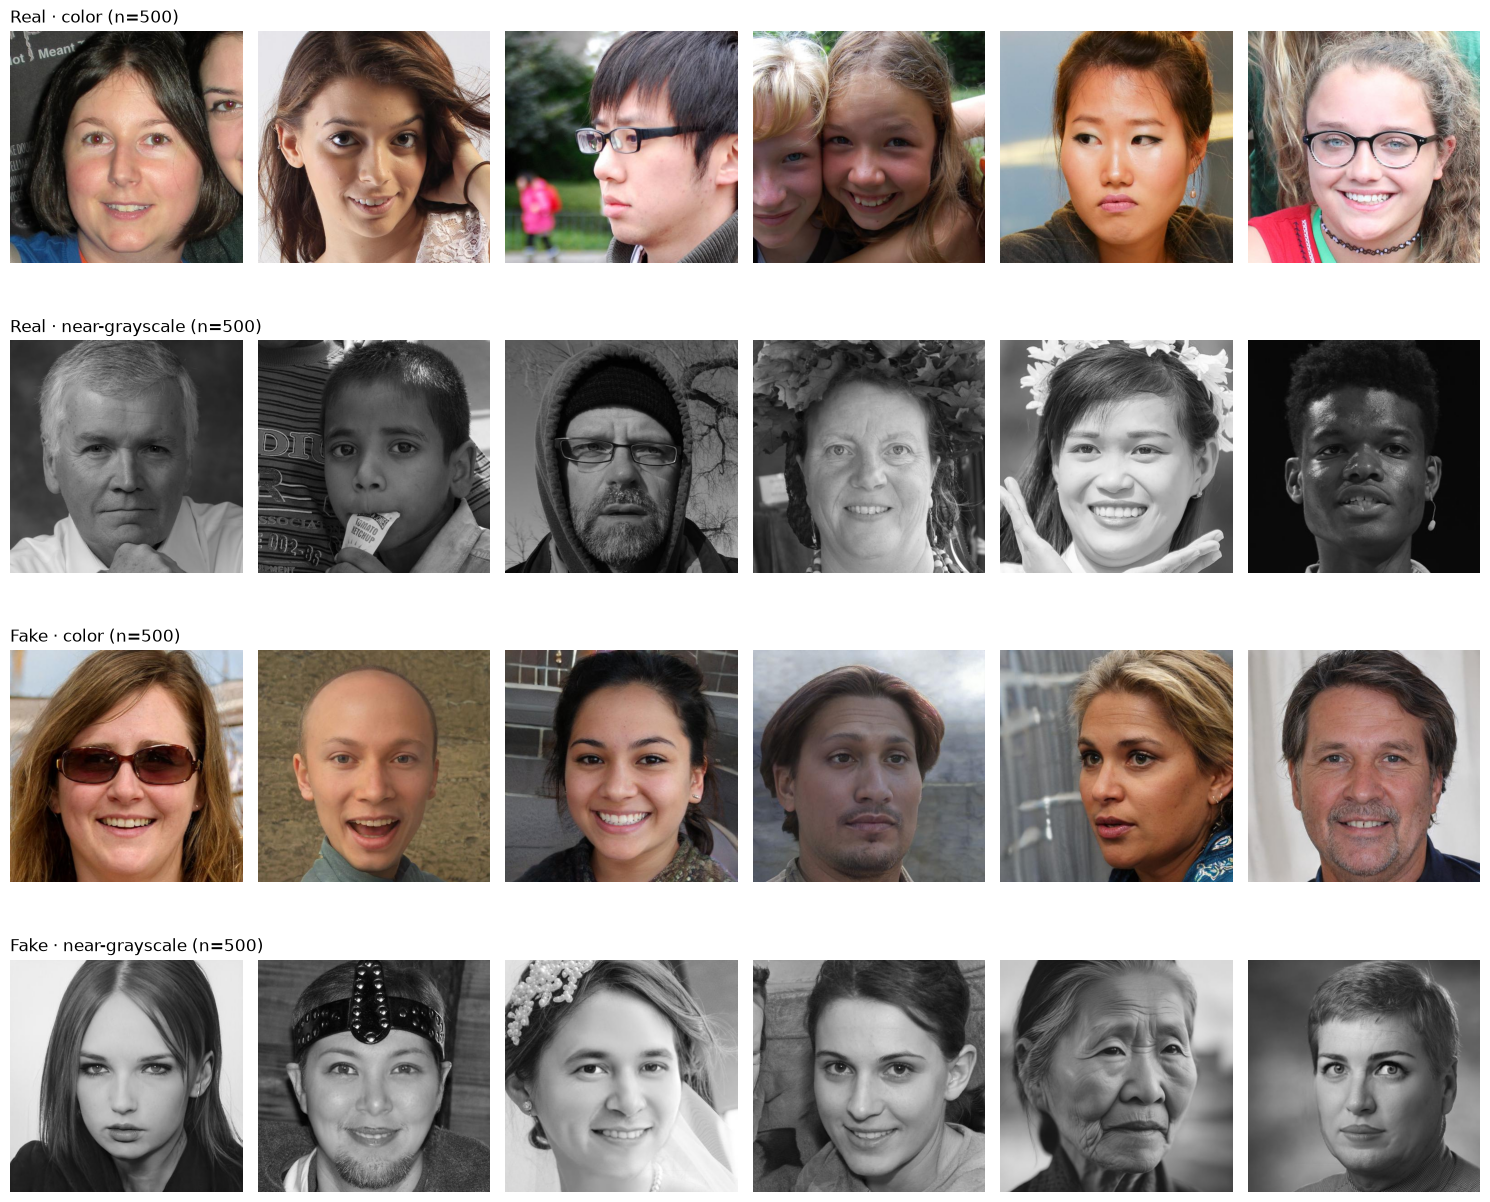

In [15]:
rng = random.Random(SEED)
train_rows = train_audit.copy()
train_rows["visual_group"] = np.where(train_rows["gray_like_image"], "near-grayscale", "color")
groups = [(label, color) for label in ("Real", "Fake") for color in ("color", "near-grayscale")]
fig, axes = plt.subplots(len(groups), 6, figsize=(15, 3.2 * len(groups)))
for row_idx, (label_name, color_name) in enumerate(groups):
    subset = train_rows[(train_rows["label_name"] == label_name) & (train_rows["visual_group"] == color_name)]
    chosen = rng.sample(list(subset["image_path"]), min(6, len(subset))) if len(subset) else []
    for col_idx, ax in enumerate(axes[row_idx]):
        ax.axis("off")
        if col_idx < len(chosen):
            with Image.open(chosen[col_idx]) as im:
                ax.imshow(ImageOps.exif_transpose(im).convert("RGB"))
    axes[row_idx, 0].set_title(f"{label_name} · {color_name} (n={len(subset)})", loc="left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "balanced_montage.png", dpi=140, bbox_inches="tight")
plt.show()

## 7. Ghi artifacts và kết luận audit

Lưu một bảng thống kê theo lớp và bảng image-level để các bước sau truy vết được. Các kết luận về shortcut phải nêu rõ đây là dấu hiệu cần kiểm tra, chưa phải bằng chứng nhân quả.

In [16]:
summary_path = REPO_ROOT / "outputs" / "dataset_summary.csv"
image_audit_path = OUTPUT_DIR / "image_audit.csv"
summary.to_csv(summary_path, index=False)
image_audit.to_csv(image_audit_path, index=False)

# Tóm tắt inventory split (test không có label thì chỉ thống kê số ảnh/đặc tính kỹ thuật).
inventory = (image_audit.groupby("split", dropna=False)
             .agg(n_images=("image_id", "count"), n_valid=("valid_image", "sum"),
                  n_dimensions=("width", lambda x: x.dropna().astype(str).nunique()),
                  mean_file_size_bytes=("file_size_bytes", "mean"))
             .reset_index())
print("Saved:", summary_path)
print("Saved:", image_audit_path)
display(inventory)
display(summary)

print("\nAudit notes to resolve before splitting:")
print("- Source/generator available:", bool(source_candidates))
print("- Train class balance:", train_audit["label_name"].value_counts(dropna=False).to_dict())
print("- Near-grayscale rate by class:", train_audit.groupby("label_name")["gray_like_image"].mean().to_dict())
print("- Exact duplicate groups:", len(duplicate_groups))
print("\nPublic/private test have no labels in the current files; do not compute evaluation metrics on them.")

Saved: /home/toska/code/aio/FaceTrace/outputs/dataset_summary.csv
Saved: /home/toska/code/aio/FaceTrace/outputs/dataset_audit/image_audit.csv


,split,n_images,n_valid,n_dimensions,mean_file_size_bytes
0,private_test,200,200,1,64705.8900
1,public_test,200,200,1,64445.4300
2,train,2000,2000,1,63891.1785


,split,label_name,n_images,n_gray_like,gray_like_fraction,n_formats,formats,file_size_bytes_mean,file_size_bytes_std,file_size_bytes_median,...,edge_mean_median,mean_R_mean,mean_R_std,mean_R_median,mean_G_mean,mean_G_std,mean_G_median,mean_B_mean,mean_B_std,mean_B_median
0,train,Fake,1000,500,0.5,1,JPEG,58701.534,14247.352550,57690.5,...,8.247614,118.521489,27.836956,118.345007,108.540493,26.289180,107.191545,103.214409,28.013086,102.336075
1,train,Real,1000,500,0.5,1,JPEG,69080.823,14361.159328,67707.5,...,10.627920,123.024634,30.301949,121.985411,110.654078,28.711268,109.188595,105.266995,30.834959,104.564493



Audit notes to resolve before splitting:
- Source/generator available: False
- Train class balance: {'Real': 1000, 'Fake': 1000}
- Near-grayscale rate by class: {'Fake': 0.5, 'Real': 0.5}
- Exact duplicate groups: 0

Public/private test have no labels in the current files; do not compute evaluation metrics on them.
